In [3]:
from source.models import Models
from source.morph2 import Morph
import numpy as np
from aeon.datasets import load_classification
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# load the data
X, y = load_classification('ECG200')
le = LabelEncoder()
y = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# train model 
lstm = Models('lstm', X_train, y_train)
lstm.train_lstm()
catch = Models('catch22', X_train, y_train)
catch.train_catch22()
rocket = Models('rocket', X_train, y_train)
rocket.train_rocket()

# compute morphing 
morphing = Morph(X_test, y_test, np.unique(y)[0])
morphing.get_DTWGlobalBorderline(X_test.shape[0])
results = morphing.CalculateMorph([lstm, catch, rocket], use_dba=True)

for model in results.keys():
    data = results[model]['metrics']
    print(f"Model: {model}")
    print(f"tsMIST_Avg: {data['mean']}")
    print(f"tsMIST_Std: {data['std']}")

/home/isabel.brito/.pyenv/versions/3.12.0/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
100%|██████████| 40/40 [00:21<00:00,  1.83it/s]

Model: lstm
tsMIST_Avg: 0.20750000000000002
tsMIST_Std: 0.0960143218483576
Model: catch22
tsMIST_Avg: 0.43714285714285717
tsMIST_Std: 0.28003644077738404
Model: rocket
tsMIST_Avg: 0.5028571428571428
tsMIST_Std: 0.27809116109209764


In [5]:
from source.models import Models
from source.morph2 import Morph
import numpy as np
from aeon.datasets import load_classification
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore")

# load the data
X, y = load_classification('ECG200')
le = LabelEncoder()
y = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# train model 
model = Models('inception', X_train, y_train)
model.train_inception()

# compute morphing 
morphing = Morph(X_test, y_test, np.unique(y)[0])
morphing.get_DTWGlobalBorderline(X_test.shape[0])
results = morphing.CalculateMorph([model], use_dba=True)

for model in results.keys():
    data = results[model]['metrics']
    print(f"Model: {model}")
    print(f"tsMIST_Avg: {data['mean']}")
    print(f"tsMIST_Std: {data['std']}")

2026-01-27 20:39:42.742675: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2026-01-27 20:40:25.468847: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 279ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 269ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 271ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 259ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 253ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


  2%|▎         | 1/40 [00:04<02:43,  4.20s/it]

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


2026-01-27 20:43:07.584031: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


...

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


 98%|█████████▊| 39/40 [01:08<00:01,  1.56s/it]

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


100%|██████████| 40/40 [01:09<00:00,  1.74s/it]

Model: inception
tsMIST_Avg: 0.5850000000000001
tsMIST_Std: 0.30915206614221424


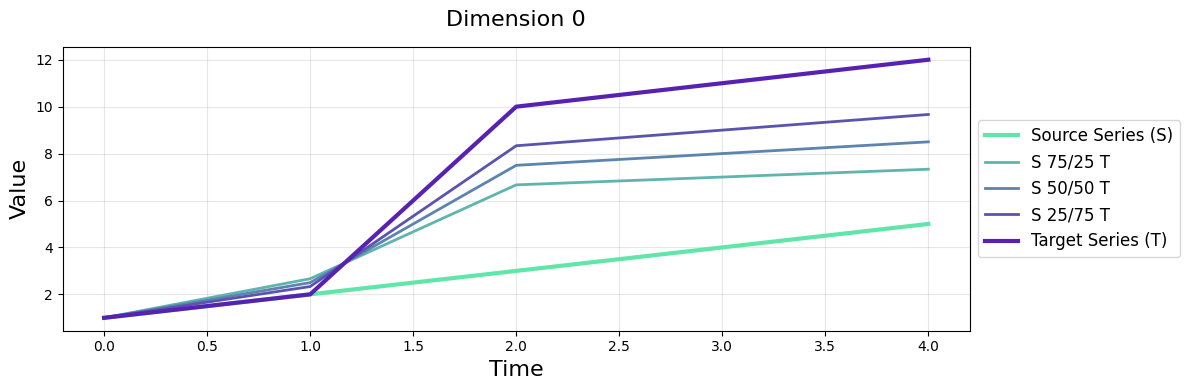

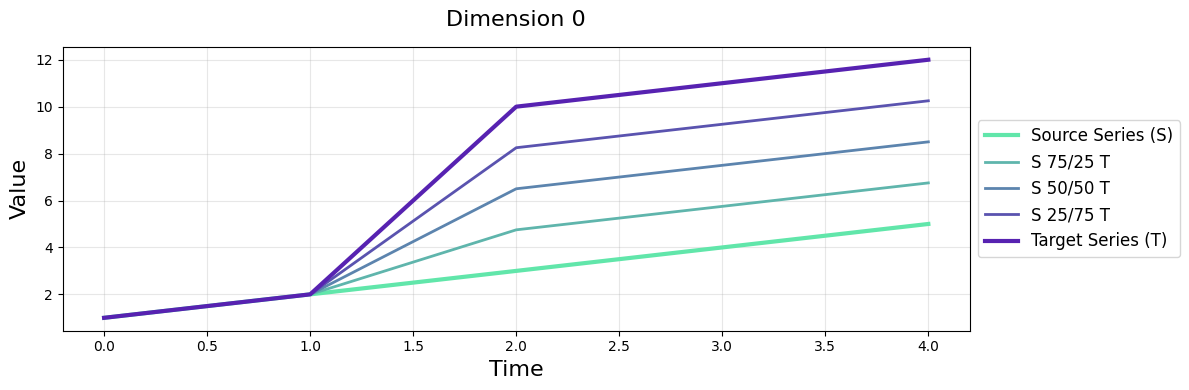

In [2]:
from source.models import Models
from source.tsmorph import TSmorph
import numpy as np
from aeon.datasets import load_classification
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import pandas as pd

def test_fit_dba():
    # Slightly different shapes to exercise DBA alignment
    S = np.array([1.0, 2.0, 3.0, 4.0, 5.0])
    T = np.array([1.0, 2.0, 10.0, 11.0, 12.0])
    morph = TSmorph(S, T, granularity=3)
    result_dba = morph.transform(use_dba=True)
    morph.plot_morphed_series(result_dba)

    result_std = morph.transform(use_dba=False)
    morph.plot_morphed_series(result_std)


test_fit_dba()